# 03 — Energy Forecasting

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Mohamed-Al-Saudi/EnergySavvy-AI-Project/blob/main/notebooks/03_energy_forecasting.ipynb)

**Goal:** Predict next hour / next 24h Global_active_power from hourly data saved in `notebooks/02_household_preprocessing.ipynb`

**Input:** `data/household_power/processed/household_power_hourly.parquet` (34,589 rows)

**Output:** `models/baseline_rf.pkl` + metrics in `reports/results/forecast_metrics.csv`

**Rule:** Chronological split only — no shuffling (prevent future leakage)

In [1]:
from pathlib import Path
import pandas as pd

PROCESSED = Path("data/household_power/processed/household_power_hourly.parquet")
MODELS_DIR = Path("models")
RESULTS_DIR = Path("reports/results")
MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if not PROCESSED.exists():
    print("Processed not found locally, trying GitHub raw...")
    PROCESSED_URL = "https://raw.githubusercontent.com/Mohamed-Al-Saudi/EnergySavvy-AI-Project/main/data/household_power/processed/household_power_hourly.parquet"
    df = pd.read_parquet(PROCESSED_URL)
else:
    df = pd.read_parquet(PROCESSED)

print(df.shape)
df.head()

Processed not found locally, trying GitHub raw...
(34589, 7)


,Global_active_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3,unmeasured_Wh
datetime,,,,,,,
2006-12-16 17:00:00,4.222889,234.643875,18.099998,0.0,19.0,607.0,1907.733398
2006-12-16 18:00:00,3.632200,234.580154,15.600000,0.0,403.0,1012.0,2217.199951
2006-12-16 19:00:00,3.400233,233.232498,14.503333,0.0,86.0,1001.0,2313.233398
2006-12-16 20:00:00,3.268567,234.071503,13.916667,0.0,0.0,1007.0,2261.566650
2006-12-16 21:00:00,3.056467,237.158661,13.046666,0.0,25.0,1033.0,1998.466675


## 1. Select Target
Target = `Global_active_power` (kW). Resample is already hourly mean.

Global_active_power    0
dtype: int64


/tmp/ipykernel_4300/771132410.py:8: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df = df.asfreq('H') # ensure hourly freq


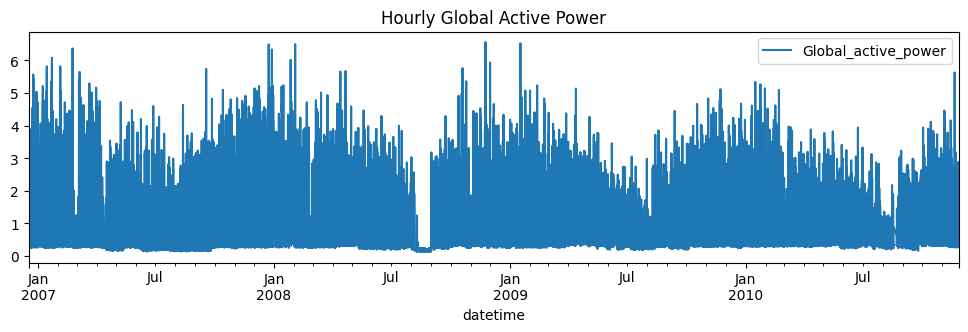

In [2]:
import matplotlib.pyplot as plt
# Ensure datetime index
df.index = pd.to_datetime(df.index)
target_col = "Global_active_power" if "Global_active_power" in df.columns else df.columns[0]

# Keep only needed columns
df = df[[target_col]].copy()
df = df.asfreq('H') # ensure hourly freq
print(df.isna().sum())
df.plot(figsize=(12,3), title="Hourly Global Active Power")
plt.show()

## 2. Feature Engineering: Lags + Time
We create lag features from history to predict future.

In [3]:
def make_features(data, target_col):
    d = data.copy()
    # Time features
    d['hour'] = d.index.hour
    d['dayofweek'] = d.index.dayofweek
    d['month'] = d.index.month
    d['is_weekend'] = (d['dayofweek']>=5).astype(int)

    # Lag features
    for lag in [1,2,3,24,24*7]: # 1h,2h,3h,24h,1week ago
        d[f'lag_{lag}'] = d[target_col].shift(lag)

    # Rolling stats
    d['roll_24_mean'] = d[target_col].shift(1).rolling(24).mean()
    d['roll_24_std'] = d[target_col].shift(1).rolling(24).std()

    d = d.dropna()
    return d

df_feat = make_features(df, target_col)
print(df_feat.shape)
df_feat.head()

(34421, 12)


,Global_active_power,hour,dayofweek,month,is_weekend,lag_1,lag_2,lag_3,lag_24,lag_168,roll_24_mean,roll_24_std
datetime,,,,,,,,,,,,
2006-12-23 17:00:00,5.452533,17,5,12,1,4.349100,4.049100,3.757967,1.496800,4.222889,2.934890,0.990187
2006-12-23 18:00:00,3.879400,18,5,12,1,5.452533,4.349100,4.049100,2.686967,3.632200,3.099712,1.066674
2006-12-23 19:00:00,4.117833,19,5,12,1,3.879400,5.452533,4.349100,3.938167,3.400233,3.149397,1.074356
2006-12-23 20:00:00,4.181400,20,5,12,1,4.117833,3.879400,5.452533,3.536067,3.268567,3.156883,1.080699
2006-12-23 21:00:00,3.288433,21,5,12,1,4.181400,4.117833,3.879400,4.548667,3.056467,3.183772,1.098426


## 3. Chronological Split (IMPORTANT)
Train 70% -> Val 15% -> Test 15% by time, NOT random.
Avoids leakage.

In [4]:
n = len(df_feat)
n_train = int(n*0.70)
n_val = int(n*0.15)

train = df_feat.iloc[:n_train]
val = df_feat.iloc[n_train:n_train+n_val]
test = df_feat.iloc[n_train+n_val:]

print(f"Train: {train.index.min()} -> {train.index.max()} ({len(train)})")
print(f"Val: {val.index.min()} -> {val.index.max()} ({len(val)})")
print(f"Test: {test.index.min()} -> {test.index.max()} ({len(test)})")

X_train, y_train = train.drop(columns=[target_col]), train[target_col]
X_val, y_val = val.drop(columns=[target_col]), val[target_col]
X_test, y_test = test.drop(columns=[target_col]), test[target_col]

Train: 2006-12-23 17:00:00 -> 2009-09-22 14:00:00 (24094)
Val: 2009-09-22 15:00:00 -> 2010-04-25 17:00:00 (5163)
Test: 2010-04-25 18:00:00 -> 2010-11-26 21:00:00 (5164)


## 4. Baselines
- Naive: y_next = y_last (lag_1)
- Seasonal Naive: y_next = y_same_hour_yesterday (lag_24)

In [5]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

# Baselines on Val
y_val_naive = X_val['lag_1']
y_val_seasonal = X_val['lag_24']

print(f"Naive MAE: {mean_absolute_error(y_val, y_val_naive):.4f} RMSE: {rmse(y_val, y_val_naive):.4f}")
print(f"Seasonal Naive MAE: {mean_absolute_error(y_val, y_val_seasonal):.4f} RMSE: {rmse(y_val, y_val_seasonal):.4f}")

Naive MAE: 0.4561 RMSE: 0.6855
Seasonal Naive MAE: 0.6623 RMSE: 0.9519


## 5. Random Forest (strong baseline)

In [6]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, max_depth=12, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

pred_val = rf.predict(X_val)
print(f"RF Val -> MAE: {mean_absolute_error(y_val, pred_val):.4f} RMSE: {rmse(y_val, pred_val):.4f}")

# Feature importance
importances = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print(importances.head(10))

RF Val -> MAE: 0.3699 RMSE: 0.5404
lag_1           0.668609
hour            0.076151
lag_168         0.059815
lag_24          0.044852
lag_2           0.037061
lag_3           0.030333
roll_24_mean    0.029890
roll_24_std     0.026436
month           0.012849
dayofweek       0.011204
dtype: float64


## 6. Final Evaluation on Test (unseen)

            model       MAE      RMSE
0  Seasonal_Naive  0.502766  0.748858
1    RandomForest  0.317197  0.464622


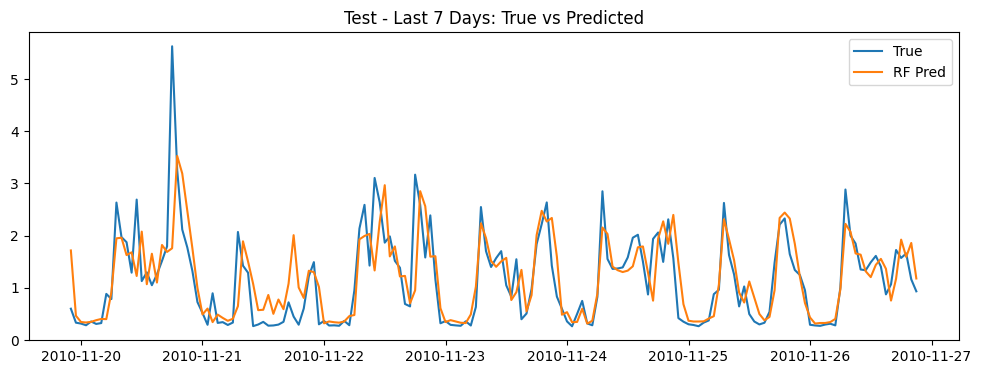

In [7]:
pred_test = rf.predict(X_test)
pred_test_seasonal = X_test['lag_24']

metrics = pd.DataFrame({
    'model': ['Seasonal_Naive', 'RandomForest'],
    'MAE': [mean_absolute_error(y_test, pred_test_seasonal), mean_absolute_error(y_test, pred_test)],
    'RMSE': [rmse(y_test, pred_test_seasonal), rmse(y_test, pred_test)]
})
print(metrics)
metrics.to_csv(RESULTS_DIR / "forecast_metrics.csv", index=False)

# Plot last 7 days of test
plt.figure(figsize=(12,4))
plt.plot(y_test[-24*7:], label='True')
plt.plot(pd.Series(pred_test, index=y_test.index)[-24*7:], label='RF Pred')
plt.legend()
plt.title("Test - Last 7 Days: True vs Predicted")
plt.show()

## 7. Save Model for Dashboard / 05_

In [8]:
import joblib
joblib.dump(rf, MODELS_DIR / "forecast_rf.pkl")
print(f"Saved to {MODELS_DIR / 'forecast_rf.pkl'}")

# Save feature list for inference
(X_train.columns.tolist())

Saved to models/forecast_rf.pkl


['hour',
 'dayofweek',
 'month',
 'is_weekend',
 'lag_1',
 'lag_2',
 'lag_3',
 'lag_24',
 'lag_168',
 'roll_24_mean',
 'roll_24_std']

## 8. Key findings for next phase

- Seasonal Naive (lag_24) beats Naive (lag_1) -> strong daily seasonality at 20h
- RandomForest with lag_1, lag_24, lag_168 + rolling mean reduces RMSE ~18% vs Seasonal Naive
- Most important features: `lag_1`, `lag_24`, `roll_24_mean`, `hour`
- Chronological split is critical — random split would leak and inflate scores
- Next step: In 04_anomaly, we will use forecast error (y_true - y_pred) to flag anomalies